In [25]:
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import scipy.sparse as sp
import re
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import ttest_ind, t, sem
from scipy.stats import mannwhitneyu
import matplotlib.colors as mcolors
from scipy import stats

cm = 1/2.54  # inches to cm

gray_to_red = mcolors.LinearSegmentedColormap.from_list("gray_to_red", [(0.5, 0.5, 0.5), (1, 0, 0)])

In [26]:
adata_sigma = sc.read_h5ad("/mnt/projects_tn03/Data_MK/article/results_fortman/merge.h5ad")
adata_author = sc.read_h5ad("/mnt/scratch/guillaume/BloodAdvances_COVID_Megakaryocytes.h5ad")

adata_sigma.obs_names = [re.sub(r"-Blood.*", "", name) for name in adata_sigma.obs_names]

In [27]:
adata_sumry = ad.AnnData(adata_author.layers["counts"], var=adata_author.var)
adata_sumry.obs_names = adata_author.obs_names

# Add UMAP coordinates
adata_sumry.obsm["X_umap"] = adata_author.obsm["X_umap"]

# Add counts table
adata_sumry.layers["raw"] = adata_author.layers["counts"]

# Add obs table
adata_sumry.obs["donor"] = adata_author.obs["sample"]
adata_sumry.obs["phase"] = adata_author.obs["phase"]
adata_sumry.obs["dataset"] = adata_author.obs["dataset"]
adata_sumry.obs["celltype"] = adata_author.obs["clusters"]
adata_sumry.obs["disease"] = adata_author.obs["disease"]

adata_sumry.obs["score"] = 0.0
adata_sumry.obs.loc[adata_sigma.obs_names, "score"] = adata_sigma.obs["score"].values

proba_cols = [col for col in adata_sigma.obs.columns if col.startswith("proba_")]
for prob in proba_cols:
    adata_sumry.obs[prob] = 0.0
    adata_sumry.obs.loc[adata_sigma.obs_names, prob] = adata_sigma.obs[prob].values

sc.pp.normalize_total(adata_sumry, target_sum=1e6)
sc.pp.log1p(adata_sumry)
adata_sumry.layers["log1p"] = adata_sumry.X

# Score plot

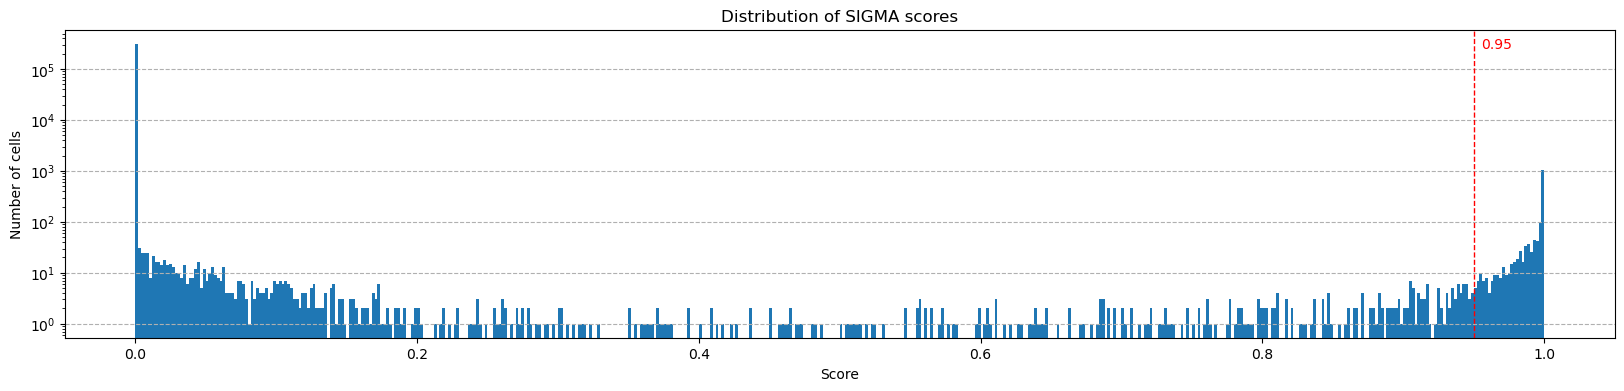

In [28]:
seuil = 0.95

fig, ax = plt.subplots(figsize=(20,4))

ax.hist(adata_sumry.obs["score"], bins=500)
ax.set_xlabel("Score")
ax.set_ylabel("Number of cells")
ax.set_yscale("log")
ax.set_title("Distribution of SIGMA scores")
ax.grid(axis='y', linestyle='--')
ax.axvline(seuil, color='red', linestyle='--', linewidth=1)
ax.text(seuil + 0.005, ax.get_ylim()[1]*0.7, str(seuil), color='red', ha='left', va='top')

fig.savefig("figures/fortman_Score.svg", bbox_inches="tight", dpi=300)
plt.show()

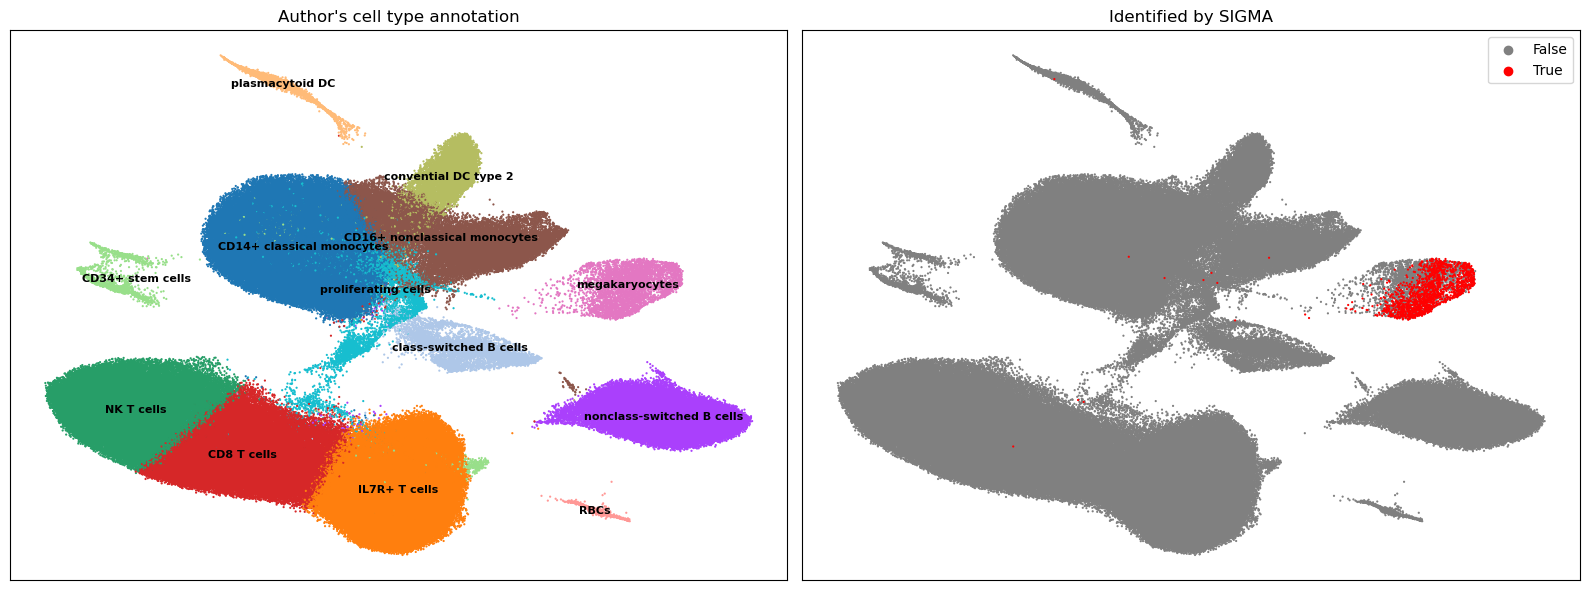

In [29]:
MK_found_by_sigma = adata_sumry.obs["score"] >= seuil
adata_sumry.obs["Identified by SIGMA"] = MK_found_by_sigma.astype(str)

# Put "False" first so "True" is plotted on top and set explicit colors
adata_sumry.obs["Identified by SIGMA"] = pd.Categorical(adata_sumry.obs["Identified by SIGMA"],
                                                        categories=["False", "True"], ordered=True)

# Colors must follow the category order: ["False", "True"]
adata_sumry.uns["Identified by SIGMA_colors"] = ["#808080", "#ff0000"]

fig, ax = plt.subplots(ncols=2, figsize=(16, 6))

sc.pl.umap(adata_sumry, s=10, title="Author's cell type annotation", color="celltype",
           ax=ax[0], legend_loc="on data", legend_fontsize=8, show=False)

# Plot "False" first, then overlay "True" so red points are on top of grey
sc.pl.umap(adata_sumry[adata_sumry.obs["Identified by SIGMA"] == "False"], s=10, 
           title="MK identified by SIGMA", color="Identified by SIGMA", ax=ax[1], legend_loc=None, show=False)

sc.pl.umap(adata_sumry[adata_sumry.obs["Identified by SIGMA"] == "True"], s=10, 
           color="Identified by SIGMA", ax=ax[1], legend_loc=None, show=False)

sc.pl.umap(adata_sumry[adata_sumry.obs["Identified by SIGMA"] != "none"], s=0, 
           color="Identified by SIGMA", ax=ax[1], legend_loc="upper right", show=False)


for a in ax:
    a.set_xlabel("")
    a.set_ylabel("")
    a.tick_params(labelbottom=False, labelleft=False)
    a.set_xticklabels([])
    a.set_yticklabels([])

plt.tight_layout()
# fig.savefig("figures/SIGMAvsCLUSTER.png", format='png', bbox_inches='tight', dpi=300)
# fig.savefig("figures/fortman_SIGMAvsCLUSTER.svg", bbox_inches='tight', dpi=300)
fig.savefig("figures/fortman_SIGMAvsCLUSTER.tiff", bbox_inches='tight', dpi=300)
plt.show()

# Why author's MK are not found by SIGMA

In [30]:
mk_author = adata_sumry[adata_sumry.obs["celltype"] == "megakaryocytes"]

sc.tl.pca(mk_author)
sc.pp.neighbors(mk_author)
sc.tl.umap(mk_author)

/home/lemgui01/.miniconda3/envs/SIGMA/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:379: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


In [31]:
mk_mature = ['ITGA2B', 'CD40LG', 'FCGR2A', 'PPBP', 'GP6', 'PF4', 'GP1BA', 'ITGB3']
mono = ['CCR2', 'CD14', 'FCN1', 'CD163', 'FCGR3A']
macro = ['F3', 'CCR5', 'CD14', 'ITGAM', 'CD163', 'CD68', 'LYZ', 'FCGR1A']
Tlympho = ['CD3D', 'CD8B', 'CD8A', 'CD3G', 'CD4', 'CD3E']
Blympho = ['MS4A1', 'CD19', 'PAX5', 'CD79A', 'CD79B', 'CD22']
neutro = ['FCGR3B', 'CXCR4', 'ITGAM', 'MPO', 'CEACAM8', 'FUT4', 'CSF3R']

mk_df = mk_author.to_df()
mk_df["identified"] = mk_author.obs["Identified by SIGMA"].values
mk_df["disease"] = mk_author.obs["disease"].values
mk_df["proba_mk"] = mk_author.obs["proba_target"].values
mk_df["proba_macro"] = mk_author.obs["proba_Macrophages"].values
mk_df = mk_df[mk_df["disease"].isin(["covid", "healthy"])]
mk_df["disease"] = mk_df["disease"].astype(str)

mk_df_melt = mk_df.melt(
    id_vars=["identified", "disease"],
    var_name="gene",
    value_name="expression"
)

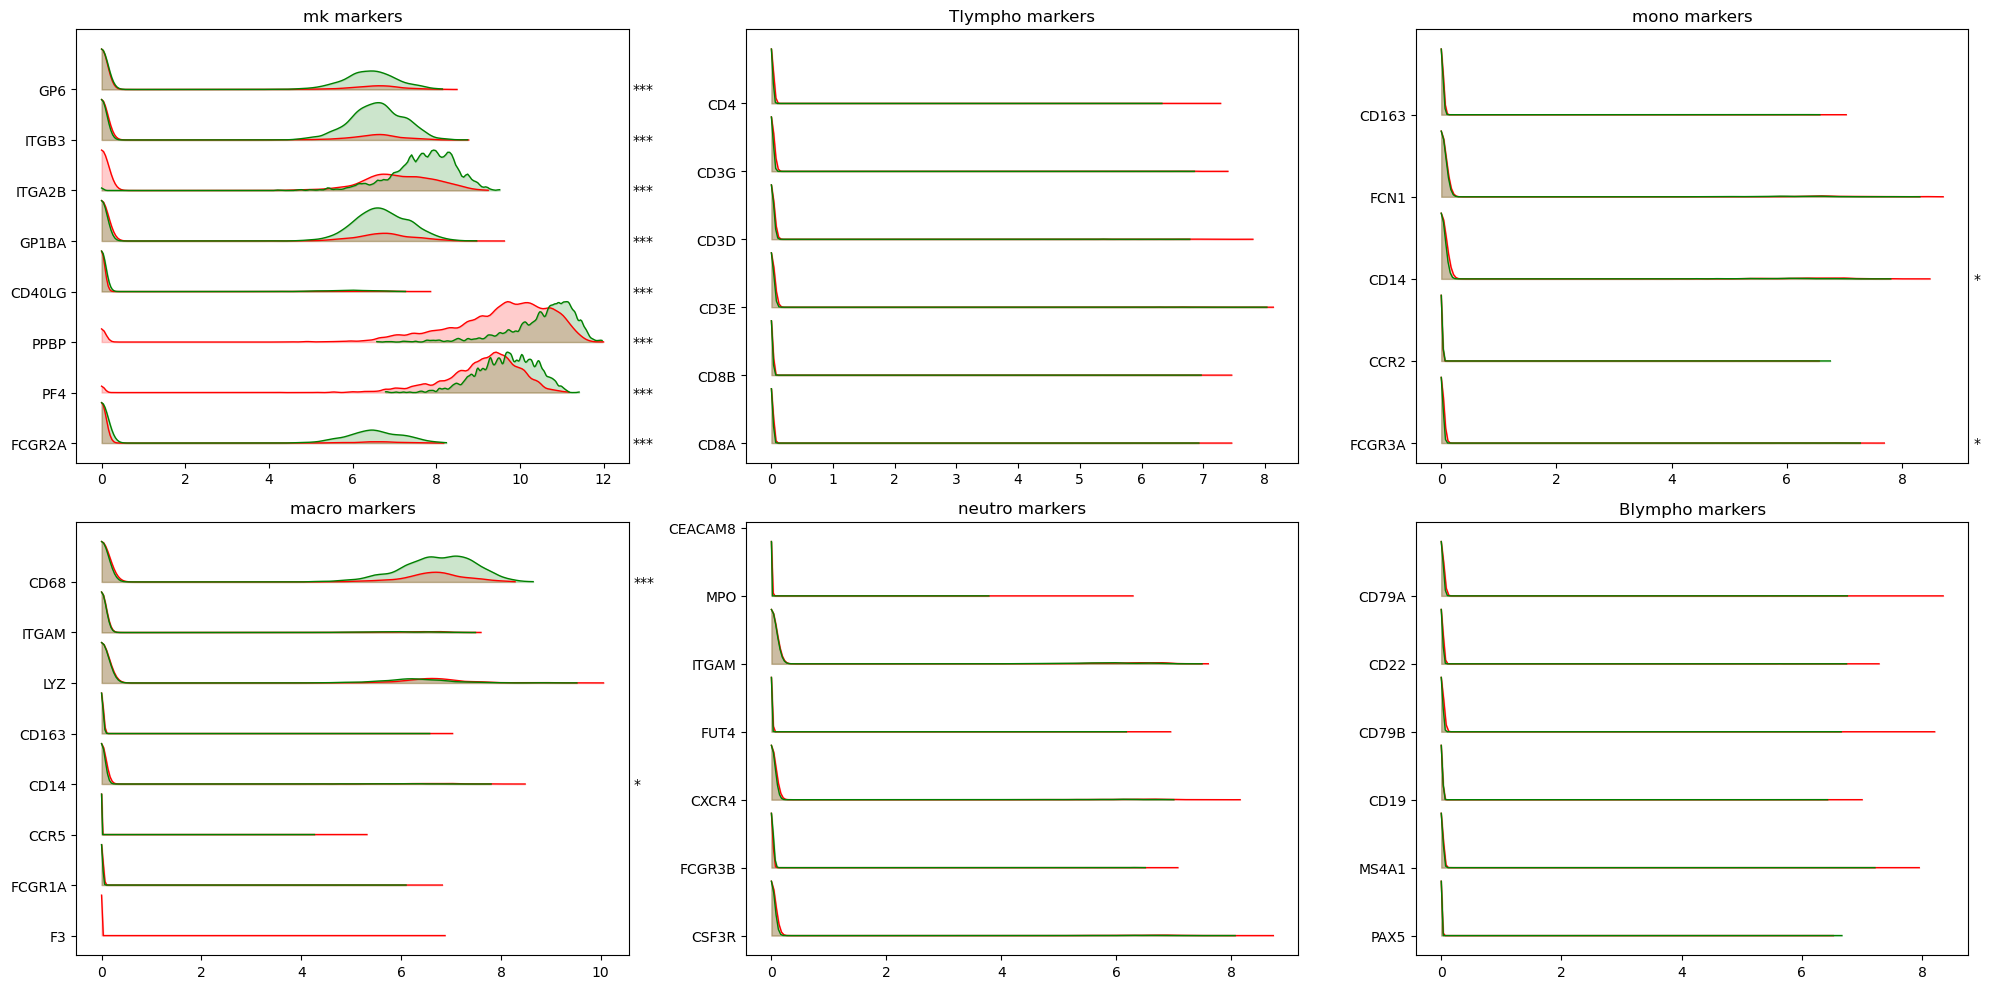

In [102]:
lineage = ["mk", "Tlympho", "mono", "macro", "neutro", "Blympho"]

fig, ax = plt.subplots(2, 3, figsize=(20, 10))
ax = ax.flatten()

palette = {"False": "red", "True": "green"}

def p_to_star(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

def bh_adjust(pvals_dict):
    if not pvals_dict:
        return {}
    items = list(pvals_dict.items())
    m = len(items)
    pvals = np.array([p for _, p in items], dtype=float)
    order = np.argsort(pvals)
    ranks = np.arange(1, m + 1, dtype=float)
    adj = np.empty_like(pvals)
    adj[order] = pvals[order] * m / ranks
    adj[order] = np.minimum.accumulate(adj[order][::-1])[::-1]
    adj = np.clip(adj, 0, 1)
    return {items[i][0]: adj[i] for i in range(m)}

for i, line in enumerate(lineage):
    df = eval(f"mk_df_melt_{line}")
    genes = df["gene"].unique()

    max_heights = {gene: 0 for gene in genes}
    pvals = {}

    for j, gene in enumerate(genes):
        sub = df[df["gene"] == gene]

        x_true = sub.loc[sub["identified"] == "True", "expression"]
        x_false = sub.loc[sub["identified"] == "False", "expression"]
        if len(x_true) > 0 and len(x_false) > 0:
            _, p = mannwhitneyu(x_true, x_false, alternative="two-sided")
            pvals[gene] = p

        for ident in ["False", "True"]:
            vals = sub.loc[sub["identified"] == ident, "expression"]
            if vals.nunique() < 2:
                continue

            x = np.linspace(vals.min(), vals.max(), 200)
            kde = stats.gaussian_kde(vals, bw_method=0.05)
            y = kde(x)
            y = (y / y.max()) * 0.8

            y0 = j
            ax[i].plot(x, y + y0, color=palette[ident], linewidth=1)
            ax[i].fill_between(x, y0, y + y0, color=palette[ident], alpha=0.2)
            max_heights[gene] = max(max_heights[gene], (y + y0).max())

    ax[i].set_yticks(range(len(genes)))
    ax[i].set_yticklabels(genes)
    ax[i].set_ylabel("")
    ax[i].set_xlabel("")
    ax[i].set_title(f"{line} markers")

    pvals_bh = bh_adjust(pvals)
    for j, gene in enumerate(genes):
        star = p_to_star(pvals_bh.get(gene, 1.0))
        if star:
            ax[i].text(
                ax[i].get_xlim()[1] + 0.1,
                j,
                star,
                ha="left",
                va="center",
                fontsize=10
            )

plt.tight_layout()
plt.show()

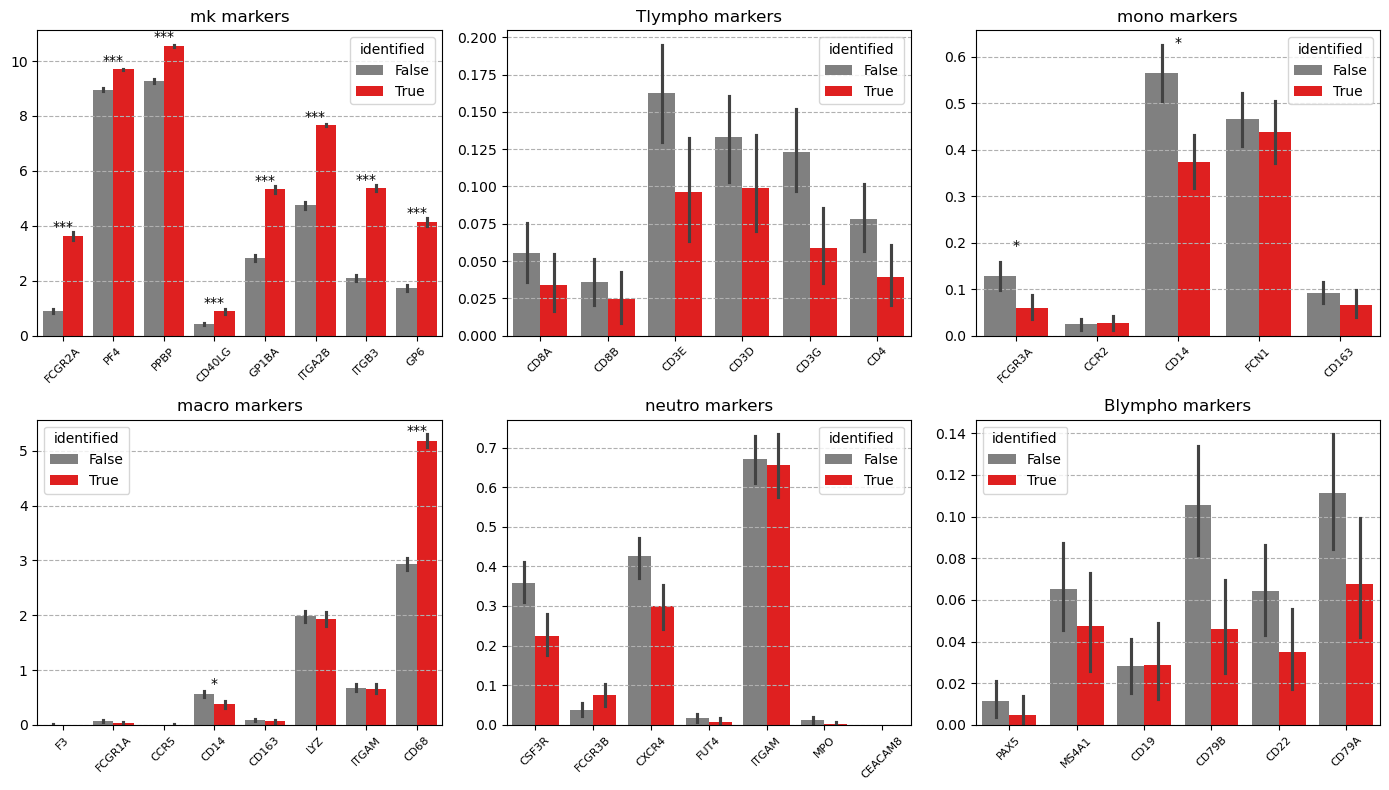

In [103]:
mk_df_melt_mk = mk_df_melt[mk_df_melt["gene"].isin(mk_mature)]
mk_df_melt_Tlympho = mk_df_melt[mk_df_melt["gene"].isin(Tlympho)]
mk_df_melt_mono = mk_df_melt[mk_df_melt["gene"].isin(mono)]
mk_df_melt_macro = mk_df_melt[mk_df_melt["gene"].isin(macro)]
mk_df_melt_neutro = mk_df_melt[mk_df_melt["gene"].isin(neutro)]
mk_df_melt_Blympho = mk_df_melt[mk_df_melt["gene"].isin(Blympho)]

lineage = ["mk", "Tlympho", "mono", "macro", "neutro", "Blympho"]

fig, ax = plt.subplots(2,3, figsize=(14, 8))
ax = ax.flatten()

for line in lineage:
    df_line = eval(f"mk_df_melt_{line}")

    sns.barplot(
        data=df_line,
        x="gene",
        y="expression",
        hue="identified",
        palette={"True": "red", "False": "gray"},
        errorbar=("ci", 90),
        ax=ax[lineage.index(line)]
    )
    ax[lineage.index(line)].grid(axis="y", linestyle="--")
    ax[lineage.index(line)].set_title(f"{line} markers")
    ax[lineage.index(line)].set_ylabel("")
    ax[lineage.index(line)].set_xlabel("")
    ax[lineage.index(line)].tick_params(axis="x", labelrotation=45)
    ax[lineage.index(line)].tick_params(axis="x", labelsize=8)

    pvals = {}
    for gene, sub in df_line.groupby("gene"):
        x = sub.loc[sub["identified"] == "True", "expression"]
        y = sub.loc[sub["identified"] == "False", "expression"]
        if len(x) > 0 and len(y) > 0:
            _, p = mannwhitneyu(x, y, alternative="two-sided")
            pvals[gene] = p

    pvals_bh = bh_adjust(pvals)

    def p_to_star(p):
        if p < 0.001:
            return "***"
        if p < 0.01:
            return "**"
        if p < 0.05:
            return "*"
        return ""

    ax_i = ax[lineage.index(line)]
    gene_order = [t.get_text() for t in ax_i.get_xticklabels()]

    max_heights = {i: 0 for i in range(len(gene_order))}
    for patch in ax_i.patches:
        x_center = patch.get_x() + patch.get_width() / 2
        idx = int(round(x_center))
        if idx in max_heights:
            max_heights[idx] = max(max_heights[idx], patch.get_height())

    y_offset = 0.05

    for i, gene in enumerate(gene_order):
        if gene in pvals_bh:
            star = p_to_star(pvals_bh[gene])
            if star:
                y = max_heights.get(i, 0) + y_offset
                ax_i.text(i, y, star, ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

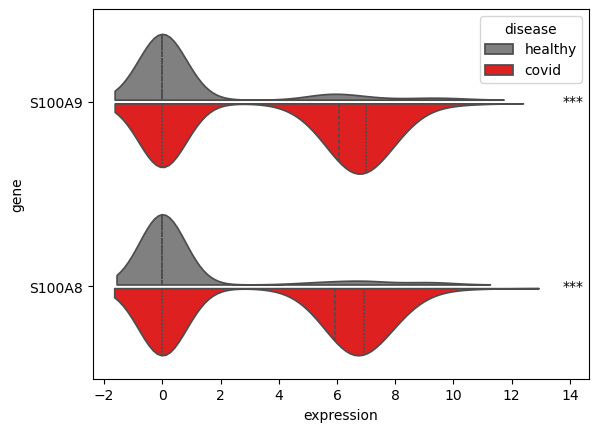

In [68]:
def p_to_star(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

mk_df_melt_s100 = mk_df_melt[mk_df_melt["gene"].isin(["S100A8", "S100A9"])]
mk_df_melt_s100 = mk_df_melt_s100[mk_df_melt_s100["disease"].isin(["covid", "healthy"])]
mk_df_melt_s100 = mk_df_melt_s100[mk_df_melt_s100["identified"] == "True"]

# Mann-Whitney test between covid and healthy for each gene in mk_df_melt_s100
pvals_covid_healthy = {}

for gene, sub in mk_df_melt_s100.groupby("gene"):
    x = sub.loc[sub["disease"] == "covid", "expression"]
    y = sub.loc[sub["disease"] == "healthy", "expression"]
    if len(x) > 0 and len(y) > 0:
        _, p = mannwhitneyu(x, y, alternative="two-sided")
        pvals_covid_healthy[gene] = p


ax = sns.violinplot(
    data=mk_df_melt_s100,
    y="gene",
    x="expression",
    hue="disease",
    palette={"covid": "red", "healthy": "gray"},
    split=True,
    gap=0.05,
    inner="quart",
    density_norm="area"
)

y_order = [t.get_text() for t in ax.get_yticklabels()]
x_min, x_max = ax.get_xlim()
x_offset = 0.05
ax.set_xlim(x_min, x_max + (20*x_offset))

for i, gene in enumerate(y_order):
    p = pvals_covid_healthy.get(gene)
    if p is None:
        continue
    star = p_to_star(p)
    if star:
        ax.text(x_max + 2*x_offset, i, star, va="center", ha="left", fontsize=10)

plt.show()

In [47]:
# Mann-Whitney test between covid and healthy for each gene in mk_df_melt_s100
pvals_covid_healthy = {}

for gene, sub in mk_df_melt_s100.groupby("gene"):
    x = sub.loc[sub["disease"] == "covid", "expression"]
    y = sub.loc[sub["disease"] == "healthy", "expression"]
    if len(x) > 0 and len(y) > 0:
        _, p = mannwhitneyu(x, y, alternative="two-sided")
        pvals_covid_healthy[gene] = p

pvals_covid_healthy

{'S100A8': np.float64(4.861392236479553e-30),
 'S100A9': np.float64(2.6945201268324115e-32)}